# Astro-RPS Bootcamp: Pandas




In this notebook and lecture, we will cover:
- Loading, filtering, and manipulating tabular data with the **pandas** package


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 

# 0. Tabular Data Handling with Numpy

Let's say we have data in a file called "GaiaM92.csv" and we want to open it in Python. One option is to use numpy:

In [2]:
data = np.genfromtxt('./GaiaM92.csv', delimiter = ',', skip_header = 1)
data

array([[ 2.59278972e+02,  4.31089818e+01,             nan, ...,
                    nan,  1.95672800e+01,             nan],
       [ 2.59289978e+02,  4.31050111e+01,             nan, ...,
                    nan,  1.84345000e+01,  6.32349000e-01],
       [ 2.59289054e+02,  4.31133782e+01,             nan, ...,
                    nan,  1.92420200e+01,             nan],
       ...,
       [ 2.59257393e+02,  4.31632966e+01, -3.17254579e+00, ...,
         1.17721990e+00,  1.90242880e+01,  6.21408460e-01],
       [ 2.59272586e+02,  4.31676046e+01, -3.12183086e-01, ...,
         4.06385234e+00,  1.78788530e+01,  6.74488070e-01],
       [ 2.59270560e+02,  4.31673887e+01, -2.00777306e-01, ...,
         1.26197385e+00,  1.91982980e+01,  7.78442400e-01]])

If we wanted to access rows, we could do the following:

In [3]:
print(data[0])

[259.27897188  43.10898178          nan          nan          nan
  19.56728             nan]


Or if we wanted to access specific columns:

In [4]:
print(data[:,0])

[259.27897188 259.28997796 259.28905426 ... 259.25739277 259.2725861
 259.27056011]


This works, but isn't very inuitive or user-friendly. Fortunately, there is a much nicer way to do the same operations using the package **pandas**!

# 1. What is Pandas, and why should I use it?

Officially, pandas is a "a fast, powerful, flexible and easy to use open source data analysis and manipulation tool" (https://pandas.pydata.org/). 

In practice, **it's a very user-friendly package for working with tabular data with Python**.

### When to use pandas

Pandas offers a convenient, easy-to-visualize interface to tabular data, including the reading/writing steps. This makes it ideal for: 

**(1)** working with small or medium-sized datasets 

**(2)** manipulating data within Jupyter notebooks, and

**(3)** exporting Python data to files.

This notebook will explore each of these cases in some form or another.

### When not to use pandas 

**(1)** The first thing to note is that **pandas is never necessary**: this is a pretty important point. There are other packages than can do everything that pandas can do, and most of its functionality can be reproduced with numpy alone. This being said, **pandas is often the most convenient/user-friendly option**. 

**(2)** This user-friendliness comes with some overhead, i.e., it makes code a bit slower. For this reason, **pandas is not a good option if you are trying to have maximally-fast code** and **not a good option for huge datasets**. 

**(3)** If you need to be very careful about datatypes, pandas is probably not the best tool to use. I almost never run into such situations, but if exporting data with datatypes is important, then csv files (which pandas excels at) are not an option, and you should consider fits files instead.

# 2. "DataFrames": pandas' key tool

The key tool that pandas introduces is the **DataFrame**. Fundamentally, it's just a 2D datastructure with rows and columns (and sometimes an index) -- i.e., it's basically a table.

## 2a. Creating a DataFrame from a file

Pandas can be a very flexible tool for loading in datafiles in many different formats. The one you might most often run into is using data contained in .csv files. Here's how you could load that with pandas:

In [5]:
filepath = './GaiaM92.csv'
df = pd.read_csv(filepath)  ## df is short for dataframe; this is fairly typical notation for pandas

**That's it!**. That's all it takes to generate a Pandas dataframe from a file. This assumes that the file itself has a row that is just the column names, but that's pretty much it on the input formatting side. Let's crack it open and see what it contains:

In [6]:
df

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN
...,...,...,...,...,...,...,...
8049,259.256567,43.162198,-0.325821,-5.009718,-0.854994,19.102306,NaN
8050,259.265129,43.164826,NaN,NaN,NaN,20.134605,0.631699
8051,259.257393,43.163297,-3.172546,-7.635612,1.177220,19.024288,0.621408
8052,259.272586,43.167605,-0.312183,-4.403949,4.063852,17.878853,0.674488


The table above looks very nice! It's clearly formatted, shows you the column names without lots of extraneous info (e.g. datatypes), etc. It even tells you the dimensions of the table!

As you can also see, there are some entries in this table that are showing "NaN" ("not a number"). And that's OK! Pandas is great at filling in missing entries from tables, which is one reason to use the package in the first place.

Now, the output of the above is obviously truncated. If you want to preview the first 5 rows, you can do:


In [7]:
df.head(10)

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN
5,259.268118,43.104699,-1.036598,-4.683732,-0.519738,19.920280,0.756393
6,259.268331,43.104789,NaN,NaN,NaN,20.417160,NaN
7,259.268817,43.106339,-0.031390,-5.688505,0.143810,19.317175,NaN
8,259.268159,43.105793,-0.770001,-1.065605,4.497394,19.669512,-0.181538
9,259.267877,43.105856,NaN,NaN,NaN,20.450974,NaN


Have a long list of columns? You can print them easily:

In [8]:
print(df.columns)

Index(['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp'], dtype='object')


## 2b. Isolating Columns!

Pandas makes it trivial to access certain columns in your data. This is in contrast to raw numpy arrays. To do so with pandas, we can simply use the following notation:

In [9]:
df['ra']

0       259.278972
1       259.289978
2       259.289054
3       259.290390
4       259.306256
           ...    
8049    259.256567
8050    259.265129
8051    259.257393
8052    259.272586
8053    259.270560
Name: ra, Length: 8054, dtype: float64

The above is what we call a **Series** in pandas. It functions basically the same as a numpy array, but carries with it an index. If you just want the values, you can add ".values" to the end:

In [10]:
df['ra'].values

array([259.27897188, 259.28997796, 259.28905426, ..., 259.25739277,
       259.2725861 , 259.27056011])

**Importantly, the above is a numpy array already**! This makes it somewhat clearer what is going on "under the hood": pandas dataframes are very similar to organized collections of numpy arrays.

If you want a single row, you will need the index of that row. For the case of index 0, this looks like:

In [11]:
df.iloc[0].values

array([259.27897188,  43.10898178,          nan,          nan,
                nan,  19.56728   ,          nan])

## 2c. Creating new columns in an existing dataframe

In [12]:
df

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN
...,...,...,...,...,...,...,...
8049,259.256567,43.162198,-0.325821,-5.009718,-0.854994,19.102306,NaN
8050,259.265129,43.164826,NaN,NaN,NaN,20.134605,0.631699
8051,259.257393,43.163297,-3.172546,-7.635612,1.177220,19.024288,0.621408
8052,259.272586,43.167605,-0.312183,-4.403949,4.063852,17.878853,0.674488


Want to use a column (or more than one!) to create a new column! It's super simple with pandas. Let's see how that works:

In [13]:
df['NewColumn'] = np.sqrt(df['pmra']**2 + df['pmdec']**2) 

Now if we re-show the dataframe, our new column will be there

In [14]:
df.head()

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,NewColumn
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349,NaN
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN,NaN
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN,6.054759
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN,4.751796


What if you have an entirely new column that is not dependent on other columns (as in the case above?). Let's see the case of adding a new column of random numbers.

In [15]:
df['NewColumn2'] = np.random.uniform(size = len(df)) ## fill new column with random numbers between 0 and 1

In [16]:
df.head()

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,NewColumn,NewColumn2
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN,NaN,0.917439
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349,NaN,0.987689
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN,NaN,0.635373
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN,6.054759,0.177638
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN,4.751796,0.722739


## 2d. Dropping columns from datafrmaes

In many cases, you may want to remove unnecessary or irrelevant columns from a DataFrame. For instance, we have added the columns `NewColumn` and `NewColumn2` to the DataFrame, but these columns might not contain useful data for the rest of the tutorial. To clean up the DataFrame, we can drop these columns.

To drop columns, we can use the `drop()` function:

In [17]:
# Drop specific columns by their column name 
df = df.drop(columns=['NewColumn', 'NewColumn2'])

In [18]:
df

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN
...,...,...,...,...,...,...,...
8049,259.256567,43.162198,-0.325821,-5.009718,-0.854994,19.102306,NaN
8050,259.265129,43.164826,NaN,NaN,NaN,20.134605,0.631699
8051,259.257393,43.163297,-3.172546,-7.635612,1.177220,19.024288,0.621408
8052,259.272586,43.167605,-0.312183,-4.403949,4.063852,17.878853,0.674488


## 2e. Other ways to load in tables:

As noted before, there's a number of other ways you can load tabular data from files. For example,

In [19]:
df2 = pd.read_csv('https://support.staffbase.com/hc/en-us/article_attachments/360009197011/username-password-recovery-code.csv')

In [20]:
df2

,Username; Identifier;One-time password;Recovery code;First name;Last name;Department;Location
0,booker12;9012;12se74;rb9012;Rachel;Booker;Sale...
1,grey07;2070;04ap67;lg2070;Laura;Grey;Depot;London
2,johnson81;4081;30no86;cj4081;Craig;Johnson;Dep...
3,jenkins46;9346;14ju73;mj9346;Mary;Jenkins;Engi...
4,smith79;5079;09ja61;js5079;Jamie;Smith;Enginee...


Oh no! It looks mangled. The problem here is that the **delimeter** is wrong. In other words, the character specifying the separation between entries is not correct. Before it was a comma (hence the "c" in csv file), but here it's a semicolon. 

Pandas can handle that. Just use the "delimeter = " argument as below:

In [21]:
df2 = pd.read_csv('https://support.staffbase.com/hc/en-us/article_attachments/360009197011/username-password-recovery-code.csv', 
                  delimiter = ';')

In [22]:
df2

,Username,Identifier,One-time password,Recovery code,First name,Last name,Department,Location
0,booker12,9012,12se74,rb9012,Rachel,Booker,Sales,Manchester
1,grey07,2070,04ap67,lg2070,Laura,Grey,Depot,London
2,johnson81,4081,30no86,cj4081,Craig,Johnson,Depot,London
3,jenkins46,9346,14ju73,mj9346,Mary,Jenkins,Engineering,Manchester
4,smith79,5079,09ja61,js5079,Jamie,Smith,Engineering,Manchester


and voila! It's fixed. The same can even be done if the delimiter is whitespace, in which case you want to use the delim_whitespace = True argument to read_csv().In short: pandas can handle data that is not simply a generic .csv file.

## 2f. Saving Dataframes

To save a dataframe (e.g., after you have made edits), one need only call .to_csv():

In [23]:
df.to_csv('Modified_data.csv')

which will save your file.

# 3. Creating Dataframes "From Scratch'': a great way to save results

Oftentimes, we don't have begin data in a file, but we want to save the data into one. For example, one situation that often comes up in research is that you have run trials / a Monte Carlo simulation and you want a way to export that information (e.g., for exact reproducibility of your plots). 

Let's generate some mock data to demonstrate this:

In [24]:
array_1 = np.random.normal(size = 1000)
array_2 = 10 * array_1 

and here's how to make that into a dataframe assuming each array above is its own column:

In [25]:
combined = np.column_stack([array_1,array_2])

In [26]:
new_dataframe = pd.DataFrame(combined)

In [27]:
new_dataframe

,0,1
0,0.541318,5.413182
1,-0.284036,-2.840359
2,-0.057782,-0.577818
3,1.568567,15.685669
4,-0.204321,-2.043207
...,...,...
995,-0.337411,-3.374114
996,0.606078,6.060781
997,-1.045249,-10.452491
998,0.705251,7.052512


This obviously doesn't have column names, but we can add them easily:

In [28]:
new_dataframe.columns = ['col1', 'col2']
new_dataframe.head()

,col1,col2
0,0.541318,5.413182
1,-0.284036,-2.840359
2,-0.057782,-0.577818
3,1.568567,15.685669
4,-0.204321,-2.043207


**Using Dictionaries**

The same can also be achieved using dictionaries and the from_dict() method. For example,

In [29]:
data_dictionary = {'col1' : array_1, 'col2' : array_2}
new_dataframe = pd.DataFrame.from_dict(data_dictionary)
new_dataframe.head()

,col1,col2
0,0.541318,5.413182
1,-0.284036,-2.840359
2,-0.057782,-0.577818
3,1.568567,15.685669
4,-0.204321,-2.043207


# 4. Filtering Data

What if we want to access subsets of the data? **It's just like numpy arrays!** You just pass the columns instead. For example,

In [30]:
filter1 = df['pmra'] > 1
filter1

0       False
1       False
2       False
3       False
4       False
        ...  
8049    False
8050    False
8051    False
8052    False
8053    False
Name: pmra, Length: 8054, dtype: bool

This generates a Series full of boolean (True/False) values. This might not be very useful on its own, but if we wanted to fully isolate the rows, we could use these booleans to create a new dataframe that meets our condtion. For example,

In [31]:
filtered_dataframe = df[filter1]

The same works with multiple conditions (and can be done in one line - just watch parantheses placement):

In [32]:
filtered_dataframe = df[(df['pmra'] > 4) & (df['pmra'] > 4)]

# 5. Handling `NaN` and Null Data in Pandas 

It is common to have `NaN` or missing values in datasets, and pandas has useful functionality for working `NaN` and null data. 

We can use `df['col'].isnull()` to detect missing data in a column. This will return a pandas Seris of boolean values indicating where data is missing.

In [33]:
df['pmra'].isnull()

0        True
1        True
2        True
3       False
4       False
        ...  
8049    False
8050     True
8051    False
8052    False
8053    False
Name: pmra, Length: 8054, dtype: bool

So, if we wanted to select for the rows where `'pmra'` is missing, we could use the above as a condition to index our DataFrame. 

In [34]:
df.loc[df['pmra'].isnull()]

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN
6,259.268331,43.104789,NaN,NaN,NaN,20.417160,NaN
9,259.267877,43.105856,NaN,NaN,NaN,20.450974,NaN
...,...,...,...,...,...,...,...
8043,259.274101,43.168850,NaN,NaN,NaN,20.607311,NaN
8044,259.261842,43.162448,NaN,NaN,NaN,19.460062,NaN
8045,259.265118,43.164086,NaN,NaN,NaN,19.972233,NaN
8046,259.259482,43.161431,NaN,NaN,NaN,20.176840,NaN


By contrast, we can check for non-null data using the `.notnull()` method, which returns a Series boolean values indicating where data is not missing.

In [35]:
df['pmra'].notnull()

0       False
1       False
2       False
3        True
4        True
        ...  
8049     True
8050    False
8051     True
8052     True
8053     True
Name: pmra, Length: 8054, dtype: bool

So, `.notnull()` and `.isnull()` are complementary functions. These functions are opposites, meaning that if one returns `True`, the other will return `False` for the same data points. You can think of them as being related by a negation operator (`~`), which inverts the result of one to get the other.

The `.dropna()` method is used to remove missing data from your DataFrame or Series. By default, it removes any rows that contain `NaN` values.

In [36]:
df['pmra'].dropna()

3      -5.808720
4      -4.624149
5      -4.683732
7      -5.688505
8      -1.065605
          ...   
8048   -5.024941
8049   -5.009718
8051   -7.635612
8052   -4.403949
8053   -0.786033
Name: pmra, Length: 4308, dtype: float64

You can also use the `axis` keyword argument to remove any columns that contain `NaN` values instead of rows. Note: now we operate on the full `df` rather than selecting one column to apply the method too. 

In [37]:
df.dropna(axis=1)

,ra,dec
0,259.278972,43.108982
1,259.289978,43.105011
2,259.289054,43.113378
3,259.290390,43.106504
4,259.306256,43.110687
...,...,...
8049,259.256567,43.162198
8050,259.265129,43.164826
8051,259.257393,43.163297
8052,259.272586,43.167605


The `.fillna()` method is another useful method, which you can use to replace missing data with a specified value

In [38]:
df['pmra'].fillna('Empty')

0          Empty
1          Empty
2          Empty
3       -5.80872
4      -4.624149
          ...   
8049   -5.009718
8050       Empty
8051   -7.635612
8052   -4.403949
8053   -0.786033
Name: pmra, Length: 8054, dtype: object

# 6. Plotting Data 

Pandas dataframe columns can be passed to matplotlib just like any other numpy array. Let's see how that works:

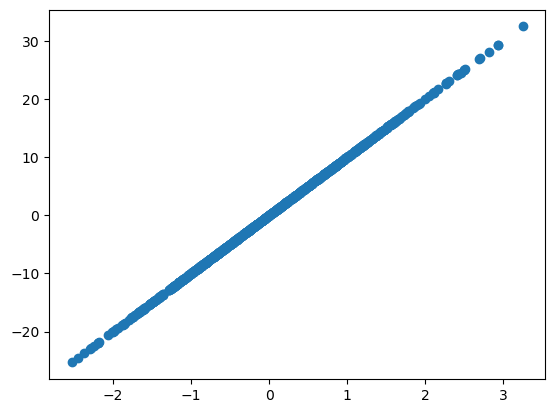

In [39]:
plt.scatter(new_dataframe['col1'], new_dataframe['col2'])

An entirely equivalent method is to do as follows:

<Axes: xlabel='col1', ylabel='col2'>

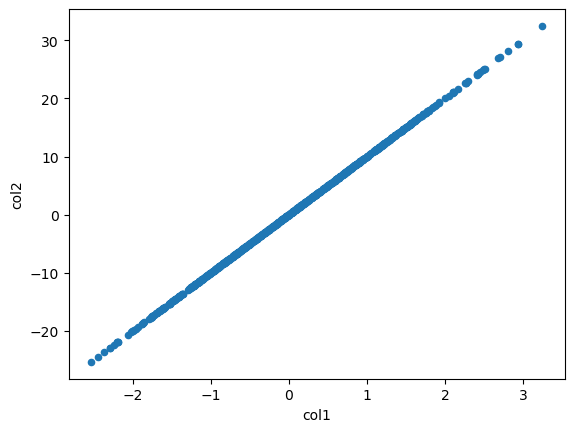

In [40]:
new_dataframe.plot.scatter('col1','col2')

This one comes with free axes labels!

# 7. Grouping Data by Categorical Labels

When we have categorical data, we may want to group rows of the dataframe together based on the value they have for a given category. 

In our case, we first create a new column called `HB`, which will flag whether each star is in the horizontal branch of the galaxy. We can define a condition that selects on brightness and color, and this condition is applied row by row to create the `HB` column with boolean values (`True` for stars on the horizontal branch and `False` otherwise).

In [41]:
# Create a new boolean column "HB" based on some condition to isolate the horizontal branch
df['HB'] = ((df['phot_g_mean_mag'] < 15.5) &
            (df['phot_g_mean_mag'] > 14.8) &
            (df['bp_rp'] < 0.7))

In [42]:
df

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,HB
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN,False
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349,False
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN,False
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN,False
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN,False
...,...,...,...,...,...,...,...,...
8049,259.256567,43.162198,-0.325821,-5.009718,-0.854994,19.102306,NaN,False
8050,259.265129,43.164826,NaN,NaN,NaN,20.134605,0.631699,False
8051,259.257393,43.163297,-3.172546,-7.635612,1.177220,19.024288,0.621408,False
8052,259.272586,43.167605,-0.312183,-4.403949,4.063852,17.878853,0.674488,False


So, the condition `(df['phot_g_mean_mag'] < 15.5) & (df['phot_g_mean_mag'] > 14.8) & (df['bp_rp'] < 0.7)` checks whether each star’s brightness and color match the criteria for the horizontal branch. Then, the new `HB` column will contain `Tru`e for stars that fit the criteria, and `False` for those that don't.

Now that we have a column with categorical data, we can check how many rows are in each category using `.value_counts()`

In [43]:
df['HB'].value_counts()

HB
False    7964
True       90
Name: count, dtype: int64

We can now group the data by the `HB` column. This allows us to easily perform operations (such as calculating the mean brightness) for stars in the horizontal branch (`True`) and those outside it (`False`) in just one line of code. 

In [44]:
df.groupby('HB')['phot_g_mean_mag'].mean()

HB
False    18.455794
True     15.256231
Name: phot_g_mean_mag, dtype: float64

In the above line, `df.groupby('HB')` groups the DataFrame by the `HB` column. Then, 
using `['phot_g_mean_mag']` selects the `phot_g_mean_mag` column from the grouped DataFrame. Using `.mean()` on this selection then calculates the mean brightness for each group (stars in the horizontal branch vs. stars outside of it) in your grouped DataFrame. 

# 8. Applying Functions to Data

Pandas also has functionality for applying functions on data columens. This is useful when you need to perform complex operations on a column of data that cannot be achieved with basic vectorized operations.

For example, we can define a function `calculate_distance_modulus()` that will take a star's brightness (magnitude) and subtract 0.3 from it to calculate the distance modulus. We can then use the `.apply()` method to apply this function to a column of data, and save the ouput as a new column. 

In [45]:
def calculate_distance_modulus(magnitude):
    return magnitude - 0.3

# Use the 'apply' method to apply the function to each element in the 'phot_g_mean_mag' column
df['DistanceModulus'] = df['phot_g_mean_mag'].apply(calculate_distance_modulus)

In [46]:
df

,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,HB,DistanceModulus
0,259.278972,43.108982,NaN,NaN,NaN,19.567280,NaN,False,19.267280
1,259.289978,43.105011,NaN,NaN,NaN,18.434500,0.632349,False,18.134500
2,259.289054,43.113378,NaN,NaN,NaN,19.242020,NaN,False,18.942020
3,259.290390,43.106504,1.533711,-5.808720,-1.708472,19.921402,NaN,False,19.621402
4,259.306256,43.110687,1.106775,-4.624149,-1.093990,19.992563,NaN,False,19.692563
...,...,...,...,...,...,...,...,...,...
8049,259.256567,43.162198,-0.325821,-5.009718,-0.854994,19.102306,NaN,False,18.802306
8050,259.265129,43.164826,NaN,NaN,NaN,20.134605,0.631699,False,19.834605
8051,259.257393,43.163297,-3.172546,-7.635612,1.177220,19.024288,0.621408,False,18.724288
8052,259.272586,43.167605,-0.312183,-4.403949,4.063852,17.878853,0.674488,False,17.578853


So, we have used the `.apply()` method to apply our custom `calculate_distance_modulus` function to the `phot_g_mean_mag` column of the DataFrame. The `apply()` method applies the function to each element of the selected column, and then we store the result to a new column called `'DistanceModulus'` using the assignment operator (equal sign). 